# 没有 DEM 和河网，怎么给中国大陆做 ParFlow 地形输入？

> **主讲人**：杨晨、徐文杰

> **日期**：2026 年 7 月


## § 0 开篇

很多人刚接触 ParFlow 时会问：模型本身是不是最难的那一块？

我们的答案是：**模型不是难处，难的是模型之前的一段——你能不能获得一套水文一致、能直接输入的地形数据**。

在北美和欧洲，有 NED/NHDPlus/NWM、EU-Hydro/EU-DEM 等直接以本地投影坐标系下的公里栅格发布的数据产品。在全球尺度上，HydroSHEDS、MERIT-Hydro、Hydrography90m 名义上也做到了 1 km 级，但它们发布在地理坐标系（经纬度）下，分辨率 30 弧秒，不是 ParFlow 需要的公里网格。

**投影意味着大量栅格的大量形变和拉伸！**

ParFlow（以及任何基于偏微分方程的物理水文模型）必须用投影坐标系下的公里方格作为输入。把全球地理栅格重投影到工作坐标系（例如中国大陆常用的 Asia Lambert Conformal Conic），重采样会让原本连通的 D4 河网在新网格上断裂。

所以涉及到一个具体的、基础数据稀缺的区域（中国大陆、非洲、中亚、南美内陆）就没用可用的现成投影栅格产品。必须从 DEM 与河网数据同时重做：DEM 要在保持水文一致性的前提下做投影转换；河网要在新投影坐标系里重新栅格化同时匹配DEM、整体是协调的。


<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_01_china_topography.jpg' alt='中国大陆地形处理结果' style='display:block; max-width:1200px; width:100%; height:auto; object-fit:contain;'></p>


## § 1 技术路线总览

从全球可得的开源数据出发，经过两个阶段得到 ParFlow 直接可用的地形输入。

1. **选 DEM**：从全球 1 km 级开源高程数据里挑一份水文一致性最好、可上采样到目标分辨率的底图。
2. **生成本地投影栅格河网**：在工作坐标系下重新跑流向、栅格化河网，避开任何地理坐标系到投影坐标系的重采样。
3. **识别内流端点 sink**：为算法明确流域的合法终点（内陆湖、沙漠尾闾、喀斯特落水洞）。
4. **drainage area 交叉验证迭代**：利用Priority Flow将把粗糙河网跑出来的 drainage area 与水文站、矢量水系、高分辨率影像比对，逐段修河网，迭代到收敛。
5. **Priority Flow**：把以上输入文件输入 *Zhang et al. 2021*（ESSD）在 CONUS 上验证过的 Priority Flood算法中，跑出最终 DEM、流向场、子流域、河网分段。
6. **slope 计算**：从最终 DEM 算 x 与 y 方向 slope，作为 ParFlow 真正使用的输入。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_02_workflow_overview.png' alt='图：地形输入完整工作流' style='display:block; max-width:720px; width:100%; height:auto; object-fit:contain;'></p>


## § 2 第一步：选 DEM

DEM 是水文建模的基础需要**精度**和**与河网的水文一致性**

### 为什么选 MERIT-DEM

我们最终选了 **MERIT-DEM**（Yamazaki et al., 2017, 2019）作为起点。这是一份全球 3 弧秒（赤道处约 90 m）的数字高程数据，它在 SRTM 的基础上做了三件水文相关的关键修正：

1. **去除树冠高度误差**——SRTM 是雷达反射顶面，森林地区会高估真实地形；MERIT 用 ICESat 激光与全球地表分类做了反演修正。
2. **去除条纹噪声**——SRTM 与 AW3D 都有方向性条纹，MERIT 用频域滤波清理。
3. **绝对垂直误差校正**——用全球 GPS 基准点做了平均偏置修正。

这三步让 MERIT-DEM 在中低起伏区（华北平原、东北平原、四川盆地等）的相对精度有显著提升，**特别适合用于大尺度水文建模**。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_03_study_domain_elevation.png' alt='图：研究区与海拔分布（中国大陆，剔除海南、台湾、南海诸岛）' style='display:block; max-width:520px; width:100%; height:auto; object-fit:contain;'></p>

### 3″ → 30″ 的转换

ParFlow 跑全国尺度时，1 km（30 弧秒）是个合理的目标分辨率。把 90 m 上采样到 1 km，如果只用简单聚合（mean / nearest），河网会在上采样后断开。我们引用的是 Eilander et al. (2021) 提出的 **Iterative Hydrography Upscaling（IHU）** 方法：在高分辨率上先算流向，再聚合，迭代直到上采样后的 D4 河网与原始 90 m 河网在拓扑上保持一致。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_04_ihu_method.png' alt='图：Iterative Hydrography Upscaling（IHU）方法' style='display:block; max-width:520px; width:100%; height:auto; object-fit:contain;'></p>


## § 3 第二步：在投影坐标系下做我们自己的河网

DEM 初步选择好之后，第二件事是河网。在缺数据地区是最大的障碍是没有成体系的河网数据——**栅格化的国家级或区域级河网产品基本是空白**，能用的几乎都是矢量产品，从矢量到 1 km 栅格的重采样在不同区域会有河道粘连、河道断开等问题。

### 为什么不能直接用全球河网产品

最方便的做法是把 MERIT-Basin（Lin et al., 2021）或者 HydroSHEDS 的矢量河网直接在 1 km 栅格上栅格化。但是会出现两类错误：

1. **坐标偏移**——全球矢量产品在中纬度地区做投影变换时，与本地基准（CGCS2000）存在 100–500 m 量级的水平偏移，在 1 km 栅格上正好跨过半个像元，导致河道发生断开或合并。
2. 矢量数据本身与DEM不适配，河网过于细密，对于1km的栅格不友好。

<div style='display:flex; gap:16px; align-items:flex-start; margin:0.6em 0 1.0em 0;'><img src='figs/figure_05_merit_basin_rivers.png' alt='MERIT-Basin river network' style='width:49%; height:auto; object-fit:contain;'><img src='figs/figure_06_river_connection_errors.png' alt='River connection errors' style='width:49%; height:auto; object-fit:contain;'></div>
### 计算河网

选用开源GIS工具 QGIS 的 **Flow Accumulation** 工具，直接在本地投影坐标系下的 MERIT-DEM 上跑出初始河网，并以 1000 km² 流域面积作为阈值二值化。后续再迭代时不断加密。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_07_qgis_flow_accumulation.png' alt='图：QGIS栅格河网' style='display:block; max-width:520px; width:100%; height:auto; object-fit:contain;'></p>

可以得到初步河网

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_08_initial_stream_mask.png' alt='图：QGIS栅格河网' style='display:block; max-width:520px; width:100%; height:auto; object-fit:contain;'></p>


## § 5 第三步：内流端点 sink 识别

中国大陆（西北河系、青藏高原内部、内蒙东部）、非洲萨赫勒、中亚、澳大利亚内陆这类有显著内流面积的地区，河流不汇入海洋而是消失在沙漠、注入封闭湖盆、或者落入喀斯特地下水系。

Sink在priority中相当于模型开始追踪上游河道的起点，如果不告诉算法这些sink在哪，Priority Flow 会强行把所有像元都排到边界外——比如在塔里木盆地一带画出一条不存在的"流向印度洋"的河道，肉眼一看就知道是错的。

所以这一步的目标是：**把所有这些sink提前标出来，作为 Priority Flow 的追踪河道的起始（sink）**。下面以中国大陆为例完整跑一遍——它三类内流端点（沙漠、湖泊、落水洞）齐全，是验证 sink 识别方法覆盖度的代表性场景。


### sink 的算法定义

我们对 sink 的栅格化定义有两个同时成立的条件：

1. **D4 全流出**：该像元在 D4 流向场（North/East/South/West 四方向）下没有任何"流入"自己——也就是说，没有任何周围栅格指向它，而它自己又流向四周中的某一个；
2. **周围8个栅格海拔最低**：该栅格海拔低于周围 8 个栅格。

两个条件交集出来的就是候选 sink。这个定义保证 sink 既是 D4 流向场上的端点，又是局部地形上的最低点——这样后续 Priority Flow 在做 depression filling 时会把这些点当成合法出口而不是要填平的洼地。**这个定义本身与区域无关，可以应用到任何地区**。

### 内/外流区在哪里分界

以中国大陆为例，内外流区分界在地理学课本里就是一条很经典的线，**和我们在地形数据里识别出来的 sink 分布几乎完全重合**：

- **北段**：大兴安岭—阴山—贺兰山—祁连山东段
- **南段**：巴颜喀拉—冈底斯山——这一段大致就是 **200 mm 年等降水量线**

线以西、以北为内流区（含塔里木、准噶尔、柴达木、青藏高原大部、内蒙东部），其余为外流区。这种"由气候分界线圈定内流区"的规律同样适用于其他缺数据大陆区域——非洲萨赫勒线、澳大利亚内陆 250 mm 等降水线、中亚干旱带都是类似机制。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_09_sink_distribution.png' alt='图：中国大陆 sink 总体分布（D4 流向场 + sink 叠加）' style='display:block; max-width:720px; width:100%; height:auto; object-fit:contain;'></p>

### 三种 sink 模式

按遥感影像核对后，我们识别到的 sink 在地理形态上可以总结成分成：

- **沙漠型（desert pattern）**：河流流入沙漠后蒸发渗失。在中国大陆主要分布于新疆塔里木盆地、内蒙古阿拉善与浑善达克沙地、甘肃河西走廊末端；典型代表是塔里木河末端——常年最末游已经断流，下游只剩季节性洪水补给的小河。同型在非洲撒哈拉边缘、中亚锡尔河末端、澳大利亚内陆都广泛存在。
- **湖泊型（lake pattern）**：河流注入封闭湖盆。在中国大陆主要分布在青藏高原内部，少量在内蒙、新疆；典型代表是西藏纳木错、青海湖一类的内陆湖。同型对应北美大盐湖、中亚咸海与里海、东非裂谷湖。
- **落水洞型（sinkhole pattern）**：河流落入喀斯特地下水系。在中国大陆主要分布在西南——贵州、广西、云南东部；典型代表是贵州地下河系统。这一类 sink 在栅格上数量最少，但识别难度最大，因为入水口在卫星影像上往往只是一个直径几十米的小洞。同型在巴尔干、佛罗里达、墨西哥尤卡坦半岛等所有喀斯特地区都存在。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_10_sink_patterns.png' alt='图：三类 sink 模式的局部示例（B 沙漠型、C 湖泊型、D 落水洞型）' style='display:block; max-width:720px; width:100%; height:auto; object-fit:contain;'></p>

### 中国大陆通过修订后共识别出来924个sink


## § 4 第四步：通过Priority flow计算drainage area 检验河网准确性


### 用 drainage area 反查河网

Flow Accumulation 跑出来的河网，每个河网像元都对应一个累积汇流面积（drainage area）。这个量是直接可验证的，拿水文站数据区对比参照，每个站的真实 drainage area 是已知的；理论上把模型跑出来的 drainage area 在站点位置取值，应该和实测一致。drainage area 在某个点发生偏差，就说明河网在哪里需要修。

我们用了三类参照数据来反查：

1. **水文站观测的 drainage area**——*Yin et al. 2024*（GSHA 数据集）发布的全球水文站点信息，研究区内有 **238 站** 可用，每站带实测 drainage area
2. **全球 IHU 数据集的 drainage area**——*Eilander et al. 2021* 在 MERIT-Hydro 基础上做的 1 km 数据集
3. **矢量水系与高分辨率影像**——MERIT-Basin 矢量、OSM 河流、Sentinel-2 L2A、天地图卫片，告诉我们河道的实际位置

### 验证一：drainage area 总体分布一致

把 Priority Flow 跑出来的 drainage area 直方图与 MERIT-Hydro 的 drainage area 直方图叠在一起看，两条曲线几乎重合——量级范围（< 100 km² 到 10⁶ km²）、形态、各 bin 频率都一致，说明计算的drainage area在统计意义上是对的。

### 验证二：像素级散点显示支流细节有差异

把 6.7 万个采样点的本工作 drainage area 与 IHU drainage area 做 pixel-by-pixel 散点，主对角线上有一条明显的高密度带——绝大多数像元两边的 drainage area 一致。但在小 drainage area（< 10⁴ km²）区有相当多偏离对角线的点，这些就是支流细节上两套数据不完全相同的地方。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_11_pf_ihu_scatter.png' alt='图：drainage area 像素级散点（本工作 PF vs IHU）' style='display:block; max-width:720px; width:100%; height:auto; object-fit:contain;'></p>

### 验证三：与 238 个水文站对比，大流域吻合、小流域系统偏差

跟 238 个水文站做对照后会看到一个有意思的现象：**大流域（> 10³ km²）的 drainage area 和实测高度吻合，但小流域（< 100 km²）有一定偏差**。主要原因是在 1 km 栅格上，小流域内部的高程变化很小，pixel 大小本身就跨过了真实小流域的尺度——这是 1 km 建模在小尺度上的天然分辨率限制。这也说明保证中大流域的准确性是前提。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_12_gauge_comparison.png' alt='图：与 238 个水文站对比的 drainage area 偏差分布与散点' style='display:block; max-width:1000px; width:100%; height:auto; object-fit:contain;'></p>

### 修正：QGIS 同屏叠合，逐段对齐

drainage area 上看到不一致的位置（特别是平原、喀斯特、内流盆地这些拓扑容易出错的地方），我们在 QGIS 里把初始河网与四套参照数据叠合同屏查看：
解决不一致的情况主要方法有加密河道和修正河道

- **MERIT-Basin 矢量河网**——主干位置参考
- **OpenStreetMap 河流矢量**——人为可辨识的河道边界参考
- **Sentinel-2 L2A 光学影像**——可见河道的实际形态参考
- **天地图卫星影像**——补充 OSM 在中国境内的密度不足

按"主干以 MERIT-Basin 为准、支流以 Sentinel-2 影像可见性为准、平原与喀斯特区以 OSM + 天地图为辅"的优先级，对每一个有疑义的河段做修正——加上漏掉的河道、删掉碎屑河源、把"漂"到错网格的河道挪回去。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_13_osm_overlay.jpg' alt='图：OSM 矢量与本工作河网在 QGIS 中同屏叠合修正示意' style='display:block; max-width:700px; width:100%; height:auto; object-fit:contain;'></p>

### 迭代到收敛

迭代的关键不是一次性把河网画完，而是先用较保守的阈值抓住主干，再逐轮加密支流。第一版 streammask 以约 **1000 km² drainage area** 为阈值，只保留稳定的大中型河道；每修一轮后重跑 Priority Flow，得到新的 drainage area，再把本工作结果与 MERIT-Basin 河网、IHU drainage area、水文站控制面积和高分辨率影像叠到同一个地理空间中检查。如果两套 drainage area 在数值上接近、在空间上也落到同一条河谷或同一条网格化河道上，就认为该段可信；如果数值偏离或空间位置错开，就回到 QGIS 中移动、连接、删除对应河段。

在主干稳定以后，如果计算的drainage area 在100km²级别出现与遥感影像、MERIT basin数据明显有区别，或河道是一条直线的明显异常，对guide river进行加密，把guide river推进到约 **100 km² drainage area** 级别。这个阶段主要补的是 1 km 栅格上仍可表达的二、三级支流。许多判断需要人眼完成：平原区一条真实河道可能落在相邻几条 1 km 网格线之间，MERIT-Basin、IHU 和影像也可能互相冲突，因此要结合河谷形态、上下游连通性和 drainage area 是否连续来取舍。最终河网在 988 万中国大陆像元里标出 **119 万** 个河网像元，密度约 **12.04%**，平均每 3 km 左右一条网格化河道，覆盖大部分主要支流。

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_14_final_stream_network.png' alt='图：从 1000 km² 主干河网加密到 100 km² 后的最终中国大陆 1 km 河网（streammask_CHN21）' style='display:block; max-width:700px; width:100%; height:auto; object-fit:contain;'></p>

这一步无法完全自动化的根本原因有三：（1）1 km 分辨率天然漏掉一部分河道，只能加密到模型分辨率允许的支流级别；（2）平原段坐标偏移需要人眼判断应对齐到哪条网格线；（3）MERIT-Basin、IHU、OSM、卫星影像和水文站数据本身会有局部冲突，需要按区域情境取舍。因此真正可复用的是工序，而不是某一个固定阈值：**"1000 km² 主干初版 → Priority Flow 计算 drainage area → 与 MERIT-Basin/IHU/水文站/影像做空间对照 → 人工修正 → 加密到 100 km² → 再迭代到收敛"**。下一次给其余区域或者不同分辨率的模型使用时，参照数据会换成当地可得的高清影像、矢量数据和水文站，以及不同的分辨率的河道，但这套从粗到细、以 drainage area 反查的加密流程不变。


## § 6 第五步：Priority Flow 处理 —— 迭代阶段

前 4 步把三件套（`DEM_CHN.tif`、`streammask_CHN*.tif`、`sink_CHN*.tif`）准备齐了。本节进入 Priority Flow 的处理流程，但**只跑到 drainage area 这一步就停**：drainage area 是「下一轮该回 QGIS 修哪里」的判据，它和参照数据（238 站、IHU、MERIT-Basin 矢量等）在 QGIS 中叠合对比，发现偏差后回去修 `streammask`，再回到本节开头重跑。

### 6.1 config & 加载三件套

把所有迭代版本号集中在一个 cell：streammask、sink、DEM 各有独立 `ITER` 变量，下一轮迭代只改对应一处即可。输出产物全部带 `ITER` 后缀，互不覆盖。

In [1]:
from pathlib import Path
import time

import numpy as np
import rasterio
import matplotlib.pyplot as plt

from priority_flow import (
    init_queue,
    stream_traverse,
    find_orphan,
    d4_traverse_b,
    drainage_area,
    calc_subbasins,
    calc_stream_order,
    river_smooth,
    slope_calc_standard,
    fix_flat,
    riv_slope,
)

In [2]:
RUNNAME   = "xutest_china"

# === 迭代版本号（升级时各自改一处）===
ITER       = "_CHN21"   # streammask 当前迭代版本
SINK_ITER  = "_CHN17"   # sink 当前版本
DEM_ITER   = "_CHN1"    # DEM 当前版本

AREA_THRESHOLD = 200

PROJECT_DIR = Path(r"E:/PROJECT/Topography/priority_flow")
INPUT_DIR   = PROJECT_DIR / "input"
WB_DIR      = PROJECT_DIR / "wb_tmp"
OUTPUT_DIR  = PROJECT_DIR / "outputs"
WB_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 域定义文件（不随迭代变）
BORDER_TIF     = INPUT_DIR / "borderdomain_CHN3.tif"
MASK_TIF       = INPUT_DIR / "mask_CHN4.tif"
BORDERTYPE_TIF = INPUT_DIR / "bordertype_CHN3.tif"

# 随迭代变的输入
DEM_TIF   = INPUT_DIR / f"DEM{DEM_ITER}.tif"
SINK_TIF  = INPUT_DIR / f"sink{SINK_ITER}.tif"
RIVER_TIF = INPUT_DIR / f"streammask{ITER}.tif"

# Whitebox 中间产物（带 ITER 后缀，避免互覆盖）
DEM_NA_TIF       = WB_DIR / f"NA_CHINA_dem961{ITER}.tif"
DEM_SMOOTHED_TIF = WB_DIR / f"CHINA_smoothed_961{ITER}.tif"

# 文件存在性检查
for p in [BORDER_TIF, MASK_TIF, DEM_TIF, SINK_TIF, BORDERTYPE_TIF, RIVER_TIF]:
    print(f"{'OK      ' if p.exists() else 'MISSING '} {p}")

# 像素分辨率（CRS 单位，通常米）—— 直接从 mask raster 读
with rasterio.open(MASK_TIF) as _src:
    DX, DY = _src.res
    _crs   = _src.crs
print(f"grid resolution from {MASK_TIF.name}: DX={DX}, DY={DY}  (CRS={_crs})")

OK       E:\PROJECT\Topography\priority_flow\input\borderdomain_CHN3.tif
OK       E:\PROJECT\Topography\priority_flow\input\mask_CHN4.tif
OK       E:\PROJECT\Topography\priority_flow\input\DEM_CHN1.tif
OK       E:\PROJECT\Topography\priority_flow\input\sink_CHN17.tif
OK       E:\PROJECT\Topography\priority_flow\input\bordertype_CHN3.tif
OK       E:\PROJECT\Topography\priority_flow\input\streammask_CHN21.tif
grid resolution from mask_CHN4.tif: DX=961.718699413681, DY=961.7186994136811  (CRS=ESRI:102012)


In [3]:
def read_raster_raw(path):
    """Return raster as native (ny, nx) row-major array (top-down rows, left-right cols)."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        profile = src.profile
    return arr, profile

def to_pf_layout(arr_yx):
    """R: t(arr[ny:1, ])  =>  NumPy: arr[::-1, :].T   (shape becomes (nx, ny))."""
    return arr_yx[::-1, :].T

def from_pf_layout(arr_xy):
    """Inverse of to_pf_layout: (nx, ny) -> (ny, nx) raster layout."""
    return arr_xy.T[::-1, :]

def read_raster_pf(path):
    arr_yx, _ = read_raster_raw(path)
    return to_pf_layout(arr_yx)

def write_raster_pf(arr_xy, reference_tif, out_path, nodata=None):
    """Write a (nx, ny) PF-layout array as a tif, copying georeferencing from reference_tif."""
    arr_yx = from_pf_layout(arr_xy)
    with rasterio.open(reference_tif) as ref:
        profile = ref.profile.copy()
    profile.update(dtype="float32", count=1)
    if nodata is not None:
        profile["nodata"] = nodata
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(arr_yx.astype(np.float32), 1)
    return out_path

In [4]:
# Load raw (ny, nx) rasters
channel_yx,    channel_profile = read_raster_raw(RIVER_TIF)
mask_yx,       _ = read_raster_raw(MASK_TIF)
border_yx,     _ = read_raster_raw(BORDER_TIF)
dem_yx,        _ = read_raster_raw(DEM_TIF)
sinks_yx,      _ = read_raster_raw(SINK_TIF)
bordertype_yx, _ = read_raster_raw(BORDERTYPE_TIF)

ny, nx = channel_yx.shape
print(f"raster shape (ny, nx) = ({ny}, {nx})")

# Burn 1 m of stream channel into the DEM (only inside domain)
channelm_yx = channel_yx * mask_yx
dem_yx = dem_yx - channelm_yx

# Transpose all to HydroFrame layout (nx, ny)
channelmT  = to_pf_layout(channelm_yx)
demT       = to_pf_layout(dem_yx)
borderT    = to_pf_layout(border_yx)
maskT      = to_pf_layout(mask_yx)
sinksT     = to_pf_layout(sinks_yx)
bordertypeT = to_pf_layout(bordertype_yx)

# Sink border (==2 marks terminal sinks)
SborderT = np.zeros_like(sinksT)
SborderT[sinksT == 2] = 1
print(f"# sinks = {int(SborderT.sum())}")

raster shape (ny, nx) = (3927, 4865)
# sinks = 924


### 6.2 Whitebox feature-preserving 平滑

原 DEM 在山地区域噪声偏大，会让后续 priority flood 跑出大量伪洼地。用 `whitebox.WhiteboxTools.feature_preserving_smoothing` 在保留地形特征（脊线、谷线）的前提下压噪声——参数 `filter=20`、`norm_diff=15`、`num_iter=3` 。

.\whitebox_tools.exe --run="FeaturePreservingSmoothing" --dem='E:\PROJECT\Topography\priority_flow\wb_tmp\NA_CHINA_dem961_CHN21.tif' --output='E:\PROJECT\Topography\priority_flow\wb_tmp\CHINA_smoothed_961_CHN21.tif' --filter=20 --norm_diff=15 --num_iter=3 --max_diff=5 --zfactor='1' -v --compress_rasters=False

*****************************************
* Welcome to FeaturePreservingSmoothing *
* Powered by WhiteboxTools              *
* www.whiteboxgeo.com                   *
*****************************************
Reading data...
Calculating normal vectors: 0%
Calculating normal vectors: 1%
Calculating normal vectors: 2%
Calculating normal vectors: 3%
Calculating normal vectors: 4%
Calculating normal vectors: 5%
Calculating normal vectors: 6%
Calculating normal vectors: 7%
Calculating normal vectors: 8%
Calculating normal vectors: 9%
Calculating normal vectors: 10%
Calculating normal vectors: 11%
Calculating normal vectors: 12%
Calculating normal vectors: 13%
Calculating normal vecto

Updating DEM elevations (Loop 1 of 3): 31%
Updating DEM elevations (Loop 1 of 3): 32%
Updating DEM elevations (Loop 1 of 3): 33%
Updating DEM elevations (Loop 1 of 3): 34%
Updating DEM elevations (Loop 1 of 3): 35%
Updating DEM elevations (Loop 1 of 3): 36%
Updating DEM elevations (Loop 1 of 3): 37%
Updating DEM elevations (Loop 1 of 3): 38%
Updating DEM elevations (Loop 1 of 3): 39%
Updating DEM elevations (Loop 1 of 3): 40%
Updating DEM elevations (Loop 1 of 3): 41%
Updating DEM elevations (Loop 1 of 3): 42%
Updating DEM elevations (Loop 1 of 3): 43%
Updating DEM elevations (Loop 1 of 3): 44%
Updating DEM elevations (Loop 1 of 3): 45%
Updating DEM elevations (Loop 1 of 3): 46%
Updating DEM elevations (Loop 1 of 3): 47%
Updating DEM elevations (Loop 1 of 3): 48%
Updating DEM elevations (Loop 1 of 3): 49%
Updating DEM elevations (Loop 1 of 3): 50%
Updating DEM elevations (Loop 1 of 3): 51%
Updating DEM elevations (Loop 1 of 3): 52%
Updating DEM elevations (Loop 1 of 3): 53%
Updating DE

Updating DEM elevations (Loop 3 of 3): 20%
Updating DEM elevations (Loop 3 of 3): 21%
Updating DEM elevations (Loop 3 of 3): 22%
Updating DEM elevations (Loop 3 of 3): 23%
Updating DEM elevations (Loop 3 of 3): 24%
Updating DEM elevations (Loop 3 of 3): 25%
Updating DEM elevations (Loop 3 of 3): 26%
Updating DEM elevations (Loop 3 of 3): 27%
Updating DEM elevations (Loop 3 of 3): 28%
Updating DEM elevations (Loop 3 of 3): 29%
Updating DEM elevations (Loop 3 of 3): 30%
Updating DEM elevations (Loop 3 of 3): 31%
Updating DEM elevations (Loop 3 of 3): 32%
Updating DEM elevations (Loop 3 of 3): 33%
Updating DEM elevations (Loop 3 of 3): 34%
Updating DEM elevations (Loop 3 of 3): 35%
Updating DEM elevations (Loop 3 of 3): 36%
Updating DEM elevations (Loop 3 of 3): 37%
Updating DEM elevations (Loop 3 of 3): 38%
Updating DEM elevations (Loop 3 of 3): 39%
Updating DEM elevations (Loop 3 of 3): 40%
Updating DEM elevations (Loop 3 of 3): 41%
Updating DEM elevations (Loop 3 of 3): 42%
Updating DE

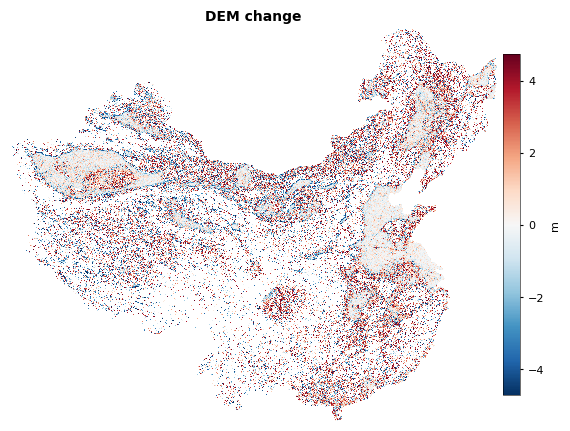

In [5]:
RUN_WHITEBOX = True

# 1) Write a NA-masked DEM as input to whitebox
var_temp = demT * maskT
var_temp_nan = np.where(maskT == 0, np.nan, var_temp)
write_raster_pf(var_temp_nan, MASK_TIF, DEM_NA_TIF, nodata=np.nan)

if RUN_WHITEBOX:
    import whitebox  # pip install whitebox
    wbt = whitebox.WhiteboxTools()
    wbt.feature_preserving_smoothing(
        dem=str(DEM_NA_TIF),
        output=str(DEM_SMOOTHED_TIF),
        filter=20,
        norm_diff=15,
        num_iter=3,
        max_diff=5,
        zfactor=1,
    )
    smoothed_yx, _ = read_raster_raw(DEM_SMOOTHED_TIF)
    demT_smooth = to_pf_layout(smoothed_yx)
else:
    demT_smooth = demT.copy()

# Set cells outside domain to a flag value (R uses -9999)
demT_smooth[maskT == 0] = -9999

# DEM difference plot (smoothed - burned), masked to changed cells
dif = demT_smooth - demT
dif_plot = np.where(dif == 0, np.nan, dif)

import matplotlib.colors as mcolors


def _white_bad_cmap(name):
    cmap = plt.get_cmap(name).copy()
    cmap.set_bad("white")
    return cmap


def _map_axis(ax, title):
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def _compact_colorbar(fig, image, ax, label=None, ticks=None):
    cb = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.015, ticks=ticks)
    cb.ax.tick_params(labelsize=8, length=2)
    if label:
        cb.set_label(label, fontsize=8)
    cb.outline.set_linewidth(0.4)
    return cb


def _robust_limits(data, symmetric=False, lower=2, upper=98):
    values = np.asarray(data, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None, None
    vmin, vmax = np.nanpercentile(values, [lower, upper])
    if np.isclose(vmin, vmax):
        vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    if symmetric:
        bound = max(abs(vmin), abs(vmax))
        if bound == 0:
            bound = 1.0
        return -bound, bound
    return vmin, vmax


fig, ax = plt.subplots(figsize=(5.6, 4.2), constrained_layout=True)
fig.patch.set_facecolor("white")

dif_yx = from_pf_layout(dif_plot)
vmin, vmax = _robust_limits(dif_yx, symmetric=True)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax) if vmin is not None else None
im = ax.imshow(dif_yx, cmap=_white_bad_cmap("RdBu_r"), norm=norm, interpolation="nearest")
_map_axis(ax, "DEM change")
_compact_colorbar(fig, im, ax, label="m")
plt.show()

# From here on, use the smoothed DEM
demT = demT_smooth


### 6.3 河网 traverse + 孤儿循环

Priority Flow 的第一步：**只在河网上跑 traverse**。让每个河网像元都能沿 D4 流向到达「合法边界」——这里 `AllBord = 域边界 + sink 边界`。第一遍跑完会有少量「孤儿河段」（与主干没连上的小支流），用 `find_orphan` + 重跑 `stream_traverse` 迭代清掉，直到孤儿数为 0。

In [19]:
AllBord = borderT + SborderT
AllBord[AllBord > 1] = 1

init = init_queue(demT, initmask=channelmT, border=AllBord)
print(f"initial queue rows: {init['queue'].shape[0]}")
print(f"total stream cells: {channelmT.sum() / 1e6:.3f} million")

t0 = time.time()
trav1 = stream_traverse(
    dem=demT,
    mask=channelmT,
    queue=init["queue"].copy(),
    marked=init["marked"].copy(),
    basins=init["basins"].copy(),
    printstep=False,
    epsilon=0,
)
t1 = time.time()
print(f"First pass: {t1 - t0:.1f} sec")
print(f"First pass: {trav1['marked'].sum() / channelmT.sum() * 100:.1f}% of stream cells processed")

# Orphan loop
lap = 1
while True:
    riv_border = borderT + SborderT + trav1["marked"]
    riv_border[riv_border > 1] = 1
    orphan = find_orphan(trav1["dem"], mask=channelmT, marked=riv_border)
    norphan = orphan["norphan"]
    print(f"lap {lap}: {norphan} orphans found")
    if norphan <= 0:
        print("Done! No orphan branches left.")
        break
    t_a = time.time()
    trav1 = stream_traverse(
        dem=trav1["dem"],
        mask=channelmT,
        queue=orphan["queue"],
        marked=trav1["marked"],
        basins=trav1["basins"],
        step=trav1["step"],
        direction=trav1["direction"],
        printstep=False,
        epsilon=0,
    )
    lap += 1
    print(f"  lap {lap} took {time.time() - t_a:.1f} sec")

print(
    f"Final pass: "
    f"{(trav1['marked'] * channelmT).sum() / channelmT.sum() * 100:.1f}% "
    f"of stream cells processed"
)
print(f"Total time: {time.time() - t0:.1f} sec")

write_raster_pf(trav1["marked"], RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.chinatravhxutest21.tif")

No domain mask provided using entire domain
initial queue rows: 1656
total stream cells: 1.190 million
First pass: 19.8 sec
First pass: 92.9% of stream cells processed
lap 1: 776 orphans found
  lap 2 took 1.6 sec
lap 2: 27 orphans found
  lap 3 took 0.3 sec
lap 3: 3 orphans found
  lap 4 took 0.3 sec
No Orphans Found
lap 4: 0 orphans found
Done! No orphan branches left.
Final pass: 100.0% of stream cells processed
Total time: 26.2 sec


WindowsPath('E:/PROJECT/Topography/priority_flow/outputs/xutest_china.chinatravhxutest21.tif')

### 6.4 山坡 d4 traverse（rivers as boundary）

河网走完后，剩下的山坡像元用 `d4_traverse_b` 处理，把已 traverse 的河网作为新边界。保证每个山坡像元都能 D4 流到河网或 sink。

In [20]:
RivBorder = borderT + trav1["marked"] + SborderT
RivBorder[RivBorder > 1] = 1

init2 = init_queue(trav1["dem"], border=RivBorder)

t4 = time.time()
travHS = d4_traverse_b(
    trav1["dem"],
    init2["queue"].copy(),
    init2["marked"].copy(),
    mask=maskT,
    direction=trav1["direction"].copy(),
    basins=trav1["basins"].copy(),
    step=trav1["step"].copy(),
    epsilon=0.1,
    printstep=False,
    n_chunk=1000,
)
print(f"Hillslope traverse: {time.time() - t4:.1f} sec")

No init mask provided all border cells will be added to queue
No domain mask provided using entire domain
Hillslope traverse: 310.9 sec


### 6.5 drainage area计算

本小节是迭代阶段的**终点**：算出 drainage area 后，把它写成 tif 带进 QGIS，与参照数据（238 站、IHU、MERIT-Basin）叠合对比。

本 notebook 内自包含的诊断包括：drainage area 直方图（log 轴）、子流域 drainage area 分位数表、全图 drainage area 渲染。外部参照（站点散点、IHU 像素散点、偏差热点图）的图位留在下方，等 QGIS 截图后填入。

In [21]:
area = drainage_area(travHS["direction"], mask=maskT, printflag=False)
write_raster_pf(area, MASK_TIF, OUTPUT_DIR / f"{RUNNAME}.area{ITER}.tif")

print(f"drainage area range: {area.min():.3g} ... {area.max():.3g} (像元数)")
print(f"drainage area > 108 像元（≈100 km²，单像元 ≈ 0.925 km²）的像元数: {int((area > 108).sum()):,}")

drainage area range: 0 ... 2.07e+06 (像元数)
drainage area > 108 像元（≈100 km²，单像元 ≈ 0.925 km²）的像元数: 846,894


C:\Users\xusun\AppData\Local\Temp\ipykernel_23996\1099880214.py:27: RuntimeWarning: divide by zero encountered in log10
  area_plot = np.where(area > 0, np.log10(area), np.nan)


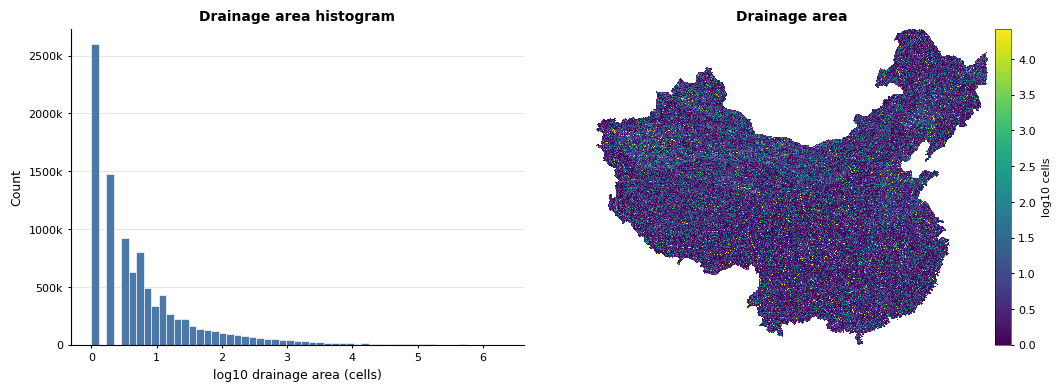

drainage area 分位数（仅统计 > 0 的域内像元）
  P   50 =            3 cells
  P   75 =           12 cells
  P   90 =           77 cells
  P   95 =          343 cells
  P   99 =        7,986 cells
  P 99.9 =      336,848 cells
  P99.99 =    1,611,708 cells


In [22]:
# drainage area 诊断：直方图 + 空间分布 + 分位数
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# from_pf_layout、_white_bad_cmap、_map_axis 等绘图辅助函数已在 6.1 中定义
area_in_domain = area[maskT > 0]
area_pos = area_in_domain[area_in_domain > 0]
log_area = np.log10(area_pos)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
fig.patch.set_facecolor("white")

# drainage area 的 log10 分布
axes[0].hist(log_area, bins=55, color="#4C78A8", edgecolor="white", linewidth=0.45)
axes[0].set_title("Drainage area histogram", fontsize=10, fontweight="bold", pad=6)
axes[0].set_xlabel("log10 drainage area (cells)", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)
axes[0].tick_params(labelsize=8, length=2)
axes[0].grid(axis="y", color="#D9D9D9", linewidth=0.6, alpha=0.8)
axes[0].set_axisbelow(True)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))

# 空间分布
area_plot = np.where(area > 0, np.log10(area), np.nan)
area_yx = from_pf_layout(area_plot)
vmin, vmax = _robust_limits(area_yx, lower=1, upper=99.5)
im = axes[1].imshow(area_yx, cmap=_white_bad_cmap("viridis"), vmin=vmin, vmax=vmax, interpolation="nearest")
_map_axis(axes[1], "Drainage area")
_compact_colorbar(fig, im, axes[1], label="log10 cells")

plt.show()

# 分位数摘要
qs = [50, 75, 90, 95, 99, 99.9, 99.99]
print("drainage area 分位数（仅统计 > 0 的域内像元）")
for q in qs:
    print(f"  P{q:>5} = {np.percentile(area_pos, q):>12,.0f} cells")


#### 迭代闭环：drainage area → QGIS 对照 → 修河网 → 重跑

把上一步写出的drainage area进行如下对比：

1. 238 个水文站（GSHA）—— 每站取本工作 drainage area，与实测做散点比对；
2. IHU 全球 1 km drainage area —— 像素级散点；
3. MERIT-Basin 矢量主干 + OSM + Sentinel-2 + 天地图 —— 看哪段河道偏移、断开或漏画；

<p style='margin: 0.6em 0 1.0em 0;'><img src='figs/figure_15_drainage_area_comparison.png' alt='图：drainage area 像素级散点（本工作 PF vs IHU）' style='display:block; max-width:1000px; width:100%; height:auto; object-fit:contain;'></p>

**收敛判据**：主干流偏差在可接受范围、且无明显大流域系统性偏差时进入 §7；否则修 `streammask`，把 `ITER`（例如 `_CHN21` → `_CHN22`）递增、再次重跑 §6.1–§6.5。本工作迭代到 `_CHN21` 收敛。

## § 7 第六步：Priority Flow 计算slope，并进行最终平滑

进入本节意味着 streammask 已经在 §6.5 的 QGIS 对照里认定收敛。接下来跑的子流域 / 河网阶 / 河道平滑 / slope 进入 ParFlow 输出最终数据集。

### 7.1 子流域 + 河流分级

用 `calc_subbasins`（阈值 `AREA_THRESHOLD = 200` 像元）把全国切成子流域，再用 `calc_stream_order` 算 Strahler 河网阶。产物同时存 GeoTIFF（地理 GIS 友好）与 npz（保留 Python 字典里的完整结构，含 segments、summary 表等）。

In [ ]:
subbasin = calc_subbasins(
    direction=travHS["direction"],
    area=area,
    mask=maskT,
    riv_th=AREA_THRESHOLD,
    merge_th=0,
)
write_raster_pf(subbasin["subbasins"], MASK_TIF, OUTPUT_DIR / f"{RUNNAME}.subbasin{ITER}.tif")

# subbasin["summary"] 列（0-based）: 0=basin_id, 1=upstream_i, 2=upstream_j,
# 3=downstream_i, 4=downstream_j, 5=downstream_basin_id, 6=area
summary    = subbasin["summary"]
basin_id   = summary[:, 0]
ds_id      = summary[:, 5]
segments   = subbasin["segments"]

stream_order = calc_stream_order(basin_id, ds_id, segments)

write_raster_pf(stream_order["order_mask"], RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.StreamOrder{ITER}.tif")
write_raster_pf(subbasin["segments"],       RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.StreamSegments{ITER}.tif")

river_mask = np.where(subbasin["segments"] > 0, 1, 0).astype(float)
write_raster_pf(river_mask, RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.RiverMask{ITER}.tif")

np.savez(
    OUTPUT_DIR / f"{RUNNAME}_subth{AREA_THRESHOLD}_SubBasins{ITER}.npz",
    **{k: v for k, v in subbasin.items()},
)
np.savez(
    OUTPUT_DIR / f"{RUNNAME}_subth{AREA_THRESHOLD}_StreamOrder{ITER}.npz",
    **{k: v for k, v in stream_order.items()},
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


def _white_bad_cmap(name):
    cmap = plt.get_cmap(name).copy()
    cmap.set_bad("white")
    return cmap


def _map_axis(ax, title):
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def _compact_colorbar(fig, image, ax, label=None, ticks=None):
    cb = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.015, ticks=ticks)
    cb.ax.tick_params(labelsize=8, length=2)
    if label:
        cb.set_label(label, fontsize=8)
    cb.outline.set_linewidth(0.4)
    return cb


def _robust_limits(data, symmetric=False, lower=2, upper=98):
    values = np.asarray(data, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None, None
    vmin, vmax = np.nanpercentile(values, [lower, upper])
    if np.isclose(vmin, vmax):
        vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    if symmetric:
        bound = max(abs(vmin), abs(vmax))
        if bound == 0:
            bound = 1.0
        return -bound, bound
    return vmin, vmax


fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6), constrained_layout=True)
fig.patch.set_facecolor("white")

segments_plot = np.where(subbasin["segments"] > 0, subbasin["segments"], np.nan)
order_plot = np.where(stream_order["order_mask"] > 0, stream_order["order_mask"], np.nan)
subbasins_plot = np.where(subbasin["subbasins"] > 0, subbasin["subbasins"], np.nan)

im0 = axes[0].imshow(from_pf_layout(segments_plot), cmap=_white_bad_cmap("tab20"), interpolation="nearest")
_map_axis(axes[0], "Segments")

max_order = int(np.nanmax(order_plot)) if np.isfinite(order_plot).any() else 1
order_cmap = _white_bad_cmap("viridis")
order_norm = mcolors.BoundaryNorm(np.arange(0.5, max_order + 1.5, 1), order_cmap.N)
im1 = axes[1].imshow(from_pf_layout(order_plot), cmap=order_cmap, norm=order_norm, interpolation="nearest")
_map_axis(axes[1], "Order")
_compact_colorbar(fig, im1, axes[1], label="order", ticks=np.arange(1, max_order + 1))

im2 = axes[2].imshow(from_pf_layout(subbasins_plot), cmap=_white_bad_cmap("tab20c"), interpolation="nearest")
_map_axis(axes[2], "Basins")

plt.show()


### 7.2 河道平滑

`river_smooth` 沿每条河段从上游到下游强制单调下降（`bank_epsilon=0.1` m），避免 Priority Flow 之后还有「河道里突然抬一格」的伪洼地。下面三联图把高程调整量按全域 / 河网 / 山坡分开显示，帮你直观判断河道下切了多少。

In [ ]:
riv_smooth_result = river_smooth(
    dem=travHS["dem"].copy(),
    direction=travHS["direction"].copy(),
    mask=maskT.copy(),
    river_summary=subbasin["summary"].copy(),
    river_segments=subbasin["segments"].copy(),
    bank_epsilon=0.1,
    printflag=True,
)

dem_adj = riv_smooth_result["dem.adj"]
dif = dem_adj - travHS["dem"]
rivmask = (subbasin["segments"] > 0).astype(float)
hillmask = 1.0 - rivmask
difhill = dif * hillmask
difriv  = dif * rivmask

dif_plot     = np.where(dif == 0, np.nan, dif)
difriv_plot  = np.where(difriv == 0, np.nan, difriv)
difhill_plot = np.where(difhill == 0, np.nan, difhill)

write_raster_pf(dif_plot,    RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.diffirst20.tif")
write_raster_pf(difriv_plot, RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.difriv20.tif")

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6), constrained_layout=True)
fig.patch.set_facecolor("white")

for ax, data, title in zip(
    axes,
    [dif_plot, difriv_plot, difhill_plot],
    ["All", "Streams", "Hillslopes"],
):
    data_yx = from_pf_layout(data)
    vmin, vmax = _robust_limits(data_yx, symmetric=True)
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax) if vmin is not None else None
    im = ax.imshow(data_yx, cmap=_white_bad_cmap("RdBu_r"), norm=norm, interpolation="nearest")
    _map_axis(ax, title)
    _compact_colorbar(fig, im, ax, label="m")

plt.show()


### 7.3 slope（standard → fix_flat → riv_slope）

三步连跑：

1. `slope_calc_standard` 按 ParFlow OverlandKinematic/OverlandDiffusive 约定算 x、y 方向坡度（`minslope=1e-4`，防止纯平地数值奇异）；
2. `fix_flat` 把连续平坦带按下游坡度比例（`adj_ratio=10`）抬一抬，避免局部平地反向流；
3. `riv_slope` 在河网像元上强制只保留主流向坡度（`remove_sec=True`），避免支流分量在 ParFlow 里造成河道反流。

In [ ]:
slopes_calc = slope_calc_standard(
    dem=dem_adj.copy(),
    direction=travHS["direction"].copy(),
    mask=maskT.copy(),
    minslope=1e-4,
    dx=DX,
    dy=DY,
    secondary_th=-1,
)

n_nan = int(np.isnan(slopes_calc["slopey"]).sum())
print(f"slopey NaNs: {n_nan}")

flat_fix = fix_flat(
    direction=travHS["direction"].copy(),
    slopex=slopes_calc["slopex"].copy(),
    slopey=slopes_calc["slopey"].copy(),
    adj_th=1e-3,
    adj_ratio=10,
    mask=maskT.copy(),
)

write_raster_pf(flat_fix["outslope"],    RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.outslope{ITER}.tif")
write_raster_pf(flat_fix["OutIn_ratio"], RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.ratio{ITER}.tif")
write_raster_pf(flat_fix["adj_mask"],    RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.adj_mask{ITER}.tif")

river_mask_only = (subbasin["segments"] > 0).astype(float)

slopes_calc2 = riv_slope(
    direction=travHS["direction"].copy(),
    slopex=flat_fix["slopex"].copy(),
    slopey=flat_fix["slopey"].copy(),
    minslope=1e-4,
    river_mask=river_mask_only,
    remove_sec=True,
)

write_raster_pf(slopes_calc2["slopex"], RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.slopex{ITER}.tif")
write_raster_pf(slopes_calc2["slopey"], RIVER_TIF, OUTPUT_DIR / f"{RUNNAME}.slopey{ITER}.tif")

slopex = slopes_calc2["slopex"]
slopey = slopes_calc2["slopey"]
print(f"slopex range: {slopex.min():.6g} ... {slopex.max():.6g}")
print(f"slopey range: {slopey.min():.6g} ... {slopey.max():.6g}")

In [ ]:
sx_plot = np.where(slopex == 0, np.nan, slopex)
sy_plot = np.where(slopey == 0, np.nan, slopey)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8), constrained_layout=True)
fig.patch.set_facecolor("white")

for ax, data, title in zip(axes, [sx_plot, sy_plot], ["Slope X", "Slope Y"]):
    data_yx = from_pf_layout(data)
    vmin, vmax = _robust_limits(data_yx, symmetric=True)
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax) if vmin is not None else None
    im = ax.imshow(data_yx, cmap=_white_bad_cmap("RdBu_r"), norm=norm, interpolation="nearest")
    _map_axis(ax, title)
    _compact_colorbar(fig, im, ax, label="slope")

plt.show()


### 7.4 ParFlow `.sa` 输出

把 slopex / slopey / 处理后 DEM / 流向场写成 ParFlow 直接使用的 `.sa` 文本格式（首行 `nx ny 1`，之后每行一个浮点）。

In [ ]:
def write_parflow_ascii(arr_xy, filepath):
    nx, ny = arr_xy.shape
    with open(filepath, "w") as f:
        f.write(f"{nx} {ny} 1\n")
        for j in range(ny):
            for i in range(nx):
                f.write(f"{arr_xy[i, j]}\n")

write_parflow_ascii(slopex,               OUTPUT_DIR / f"{RUNNAME}_SlopeX{ITER}.sa")
write_parflow_ascii(slopey,               OUTPUT_DIR / f"{RUNNAME}_SlopeY{ITER}.sa")
write_parflow_ascii(dem_adj,              OUTPUT_DIR / f"{RUNNAME}_DEM.Processed{ITER}.sa")
write_parflow_ascii(travHS["direction"],  OUTPUT_DIR / f"{RUNNAME}_Flow.Direction{ITER}.sa")

print(f"Outputs written to {OUTPUT_DIR}")


## 引用文献

1. Yang C, Jia Z, Xu W, et al. CONCN: a high-resolution, integrated surface water–groundwater ParFlow modeling platform of continental China[J]. Hydrology and Earth System Sciences, 2025, 29(9): 2201-2218.
2. Eilander, D., van Verseveld, W., Yamazaki, D., Weerts, A., Winsemius, H. C., & Ward, P. J. (2021). A hydrography upscaling method for scale-invariant parametrization of distributed hydrological models. *Hydrology and Earth System Sciences*, 25, 5287–5313.
3. Yamazaki, D., Ikeshima, D., Sosa, J., Bates, P. D., Allen, G. H., & Pavelsky, T. M. (2019). MERIT Hydro: A High‑Resolution Global Hydrography Map Based on Latest Topography Dataset. *Water Resources Research*, 55(6), 5053–5073.
4. Yamazaki, D., Ikeshima, D., Tawatari, R., Yamaguchi, T., O'Loughlin, F., Neal, J. C., Sampson, C. C., Kanae, S., & Bates, P. D. (2017). A high‑accuracy map of global terrain elevations. *Geophysical Research Letters*, 44(11), 5844–5853.
5. Lin, P., Pan, M., Wood, E. F., Yamazaki, D., & Allen, G. H. (2021). A new vector-based global river network dataset accounting for variable drainage density. *Scientific Data*, 8(1), 28.
6. Drusch, M., et al. (2012). Sentinel-2: ESA's Optical High-Resolution Mission for GMES Operational Services. *Remote Sensing of Environment*, 120, 25–36.
7. Zhang, J., Condon, L. E., Tran, H., & Maxwell, R. M. (2021). A national topographic dataset for hydrological modeling over the contiguous United States. *Earth System Science Data*, 13(7), 3263–3279.
8. Condon, L. E., & Maxwell, R. M. (2019). Modified priority flood and global slope enforcement algorithm for topographic processing in physically based hydrologic modeling applications. *Computers and Geosciences*, 126, 73–83.
